## **Approximating $e^x$ using Chebyshev Polynomials**

When approximating a continuous function like $f(x) = e^x$ over a specific interval (typically $[-1, 1]$), the standard approach is often a Taylor series. However, Taylor polynomials match the function perfectly at a single center point, causing the error to grow significantly near the edges of the interval.

**Chebyshev approximations** solve this by distributing the error evenly across the entire interval, achieving a "minimax" approximation (minimizing the maximum error). 

Instead of sampling the function at evenly spaced intervals—which can lead to wild oscillations at the edges for high-degree polynomials (Runge's phenomenon)—we sample the function at specific, clustered points called **Chebyshev nodes**.

---

### **The Mathematical Formulas**

To approximate $e^x$ using a Chebyshev polynomial of degree $N-1$, we need $N$ terms. The process involves defining the nodes, calculating the polynomials, finding the coefficients, and summing them up.

#### **1. The Chebyshev Nodes**
We evaluate our target function at $N$ specific points, which correspond to the roots of the Chebyshev polynomial. These nodes are clustered towards $-1$ and $1$. For $k = 0, 1, ..., N-1$, the nodes are calculated as:

$$x_k = \cos\left(\frac{2k + 1}{2N}\pi\right)$$

#### **2. The Chebyshev Polynomials**
The polynomials themselves, denoted as $T_j(x)$, are defined trigonometrically for $j \ge 0$:

$$T_j(x) = \cos(j \arccos(x))$$

*(Note: $T_0(x) = 1$ and $T_1(x) = x$)*

#### **3. The Chebyshev Coefficients**
To find the weight $c_j$ of each polynomial in our final approximation, we evaluate $f(x) = e^x$ at the nodes and compute the following discrete sum for each $j = 0, 1, ..., N-1$:

$$c_j = \frac{2}{N} \sum_{k=0}^{N-1} e^{x_k} T_j(x_k)$$

#### **4. The Final Approximation**
Once the coefficients are calculated, the approximation $p(x)$ is constructed by summing the polynomials multiplied by their respective coefficients. By mathematical convention, the first term ($c_0$) is divided by 2:

$$e^x \approx p(x) = \frac{c_0}{2} + \sum_{j=1}^{N-1} c_j T_j(x)$$

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def chebyshev_approx_exp(x_eval, N):
	"""
	Approximates e^x using a Chebyshev series of N terms.
	x_eval: The point(s) where we want to evaluate the approximation.
	N: The number of terms/nodes to use.
	"""
	# 1. Calculate the N Chebyshev nodes
	k = np.arange(N)
	nodes = np.cos((2 * k + 1) * np.pi / (2 * N))
	
	# 2. Evaluate the target function at the nodes
	f_nodes = np.exp(nodes)
	
	# 3. Calculate the Chebyshev coefficients (c_j)
	c = np.zeros(N)
	for j in range(N):
		# T_j evaluated at the nodes
		T_j_nodes = np.cos(j * np.arccos(nodes)) 
		c[j] = (2.0 / N) * np.sum(f_nodes * T_j_nodes)
	
	# 4. Build the final approximation for the requested x_eval points
	# Start with c_0 / 2
	approximation = np.full_like(x_eval, c[0] / 2.0, dtype=float)
	
	# Add the remaining terms: c_j * T_j(x_eval)
	for j in range(1, N):
		T_j_x = np.cos(j * np.arccos(x_eval))
		approximation += c[j] * T_j_x
	
	return approximation

In [7]:
# Create 100 points between -1 and 1 to test our function
x_test = np.linspace(-1, 1, 100)
true_y = np.exp(x_test)

# Calculate the Chebyshev approximation using 5 terms (degree 4)
N_terms = 5
approx_y = chebyshev_approx_exp(x_test, N_terms)

# Calculate the maximum error across the interval
max_error = np.max(np.abs(true_y - approx_y))
print(f"Maximum Error with {N_terms} terms: {max_error:.6f}")

Maximum Error with 5 terms: 0.000640


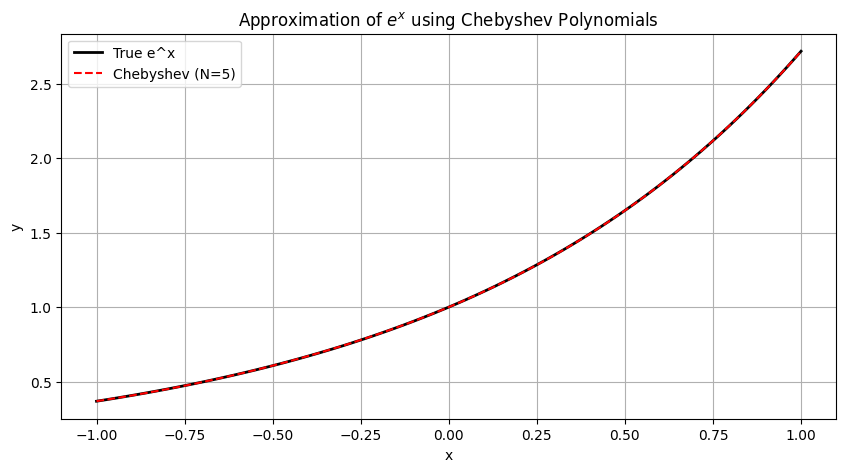

In [8]:
# Plotting the results
plt.figure(figsize=(10, 5))

plt.plot(x_test, true_y, label="True e^x", color="black", linewidth=2)
plt.plot(x_test, approx_y, label=f"Chebyshev (N={N_terms})", linestyle="--", color="red")

plt.title("Approximation of $e^x$ using Chebyshev Polynomials")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.show()

---
### **Using NumPy's Built-in**

`Chebyshev.interpolate` automatically finds the nodes, evaluates the function, and calculates the coefficients.

In [9]:
from numpy.polynomial import Chebyshev
import numpy as np

In [10]:
target_func = lambda x: np.exp(x)
cheb_poly = Chebyshev.interpolate(target_func, deg=4)

In [11]:
# Evaluate it at any point
x_test = np.linspace(-1, 1, 100)
approx_y = cheb_poly(x_test)

In [12]:
# Calculate the true values and error
true_y = np.exp(x_test)
max_error = np.max(np.abs(true_y - approx_y))
print(f"Maximum Error with NumPy's Chebyshev.interpolate: {max_error:.6f}")

Maximum Error with NumPy's Chebyshev.interpolate: 0.000640


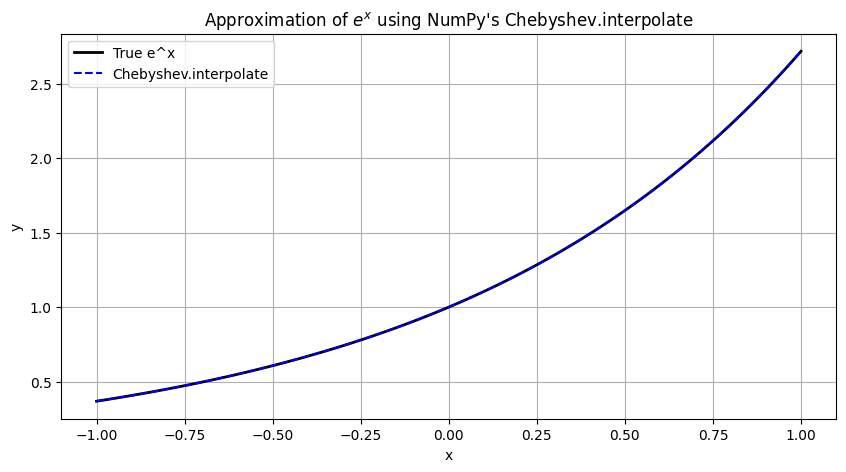

In [13]:
# Plotting the results
plt.figure(figsize=(10, 5))

plt.plot(x_test, true_y, label="True e^x", color="black", linewidth=2)
plt.plot(x_test, approx_y, label="Chebyshev.interpolate", linestyle="--", color="blue")

plt.title("Approximation of $e^x$ using NumPy's Chebyshev.interpolate")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.show()